# Phase diagram exploration

This notebook examines how social coupling and temperature change entropy, consonance, and the deliberately simple music-like texture score. The sweep uses the `harmonic_social_tuning` preset as its baseline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'exponential_random_orchestra').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')

ROOT = find_repo_root()
PHASE_PATH = ROOT / 'exponential_random_orchestra' / 'output' / 'data' / 'phase_diagram.npz'
phase = np.load(PHASE_PATH)
phase.files

['temperatures',
 'beta_social',
 'mean_entropy',
 'mean_consonance',
 'music_like_score']

In [2]:
temperatures = phase['temperatures']
social_values = phase['beta_social']
entropy = phase['mean_entropy']
consonance = phase['mean_consonance']
texture_score = phase['music_like_score']

entropy.shape, temperatures[[0, -1]], social_values[[0, -1]]

((25, 25), array([0.3, 5. ]), array([0., 3.]))

## Three views of the same parameter space

Temperature runs left to right and social coupling runs bottom to top. The score is normalized over this particular sweep, so it is useful for relative comparison rather than as an absolute measure of musicality.

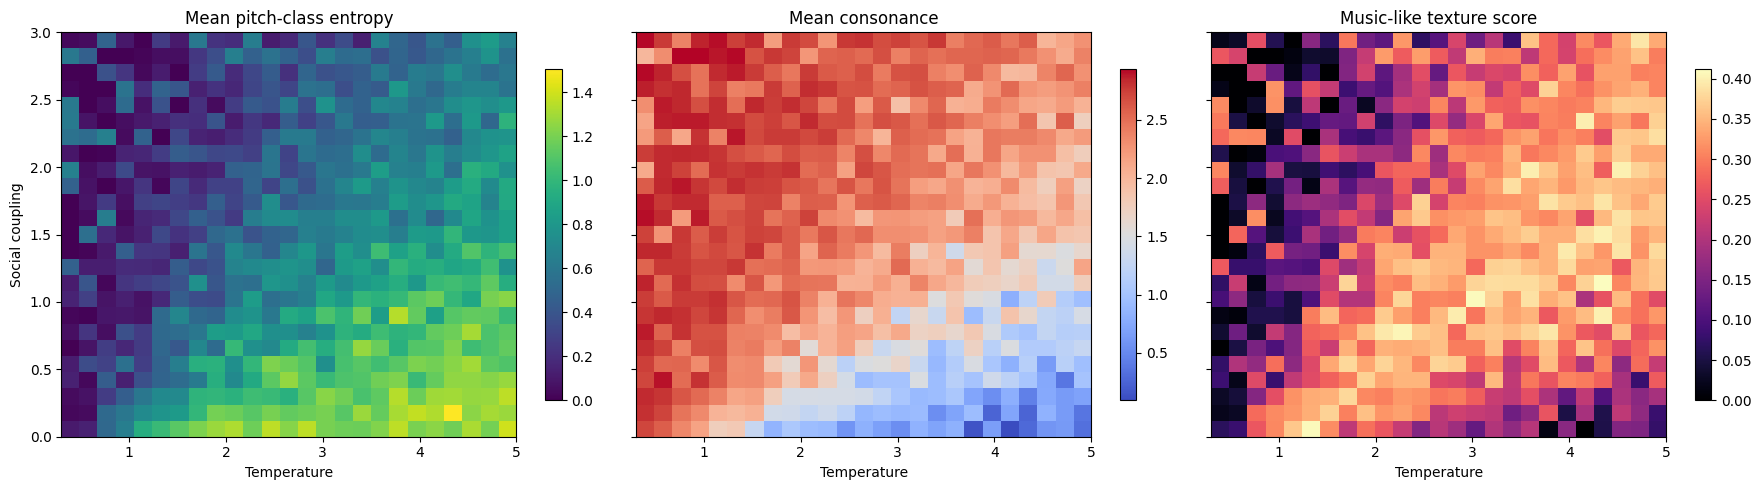

In [3]:
extent = [temperatures[0], temperatures[-1], social_values[0], social_values[-1]]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
panels = [
    (entropy, 'Mean pitch-class entropy', 'viridis'),
    (consonance, 'Mean consonance', 'coolwarm'),
    (texture_score, 'Music-like texture score', 'magma'),
]
for axis, (values, title, cmap) in zip(axes, panels):
    image = axis.imshow(values, origin='lower', aspect='auto', extent=extent, cmap=cmap)
    axis.set_title(title)
    axis.set_xlabel('Temperature')
    fig.colorbar(image, ax=axis, shrink=0.82)
axes[0].set_ylabel('Social coupling')
fig.tight_layout()

## Locate high-scoring regions

A single maximum can be unstable under random seeds, so inspect the top region rather than treating one cell as the answer.

In [4]:
rows = []
for social_index, beta_social in enumerate(social_values):
    for temperature_index, temperature in enumerate(temperatures):
        rows.append({
            'beta_social': beta_social,
            'temperature': temperature,
            'entropy': entropy[social_index, temperature_index],
            'consonance': consonance[social_index, temperature_index],
            'texture_score': texture_score[social_index, temperature_index],
        })
grid = pd.DataFrame(rows)
grid.nlargest(15, 'texture_score').round(3)

,beta_social,temperature,entropy,consonance,texture_score
246,1.125,4.412,1.044,1.785,0.412
214,1.000,3.042,0.899,2.046,0.410
5,0.000,1.279,1.020,1.809,0.408
160,0.750,2.258,0.902,2.020,0.406
321,1.500,4.412,0.990,1.834,0.402
196,0.875,4.412,1.109,1.640,0.400
422,2.000,4.608,0.958,1.882,0.400
495,2.375,4.217,0.818,2.186,0.399
417,2.000,3.629,0.836,2.134,0.398
188,0.875,2.846,0.866,2.057,0.397


beta_social      1.125
temperature      4.412
entropy          1.044
consonance       1.785
texture_score    0.412
Name: 246, dtype: float64

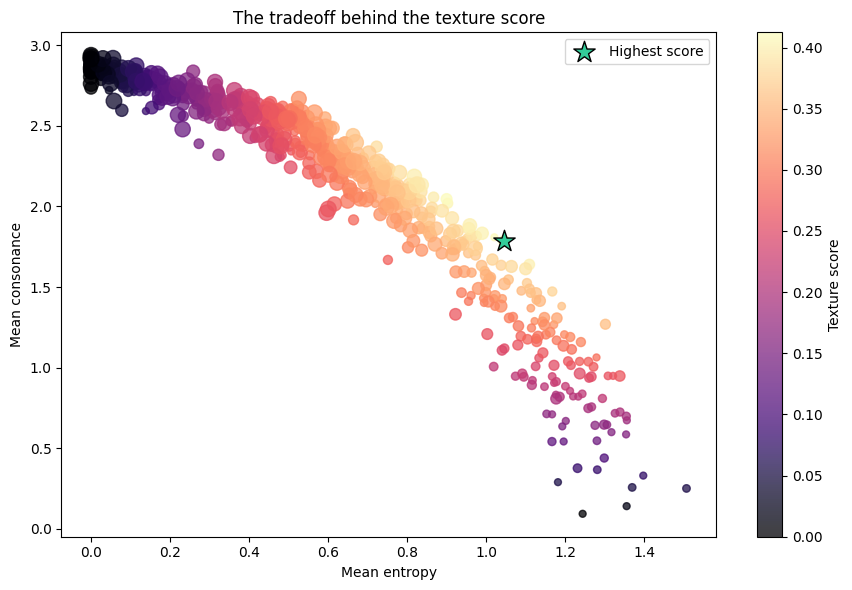

In [5]:
best = grid.loc[grid['texture_score'].idxmax()]
fig, axis = plt.subplots(figsize=(9, 6))
scatter = axis.scatter(
    grid['entropy'],
    grid['consonance'],
    c=grid['texture_score'],
    s=25 + 35 * grid['beta_social'],
    cmap='magma',
    alpha=0.75,
)
axis.scatter(best['entropy'], best['consonance'], marker='*', s=260, color='#33cc99', edgecolor='black', label='Highest score')
axis.set(xlabel='Mean entropy', ylabel='Mean consonance', title='The tradeoff behind the texture score')
axis.legend()
fig.colorbar(scatter, ax=axis, label='Texture score')
fig.tight_layout()
best.round(3)

## Parameter slices

Slices make it easier to see whether temperature has a smooth effect at fixed social coupling, and vice versa.

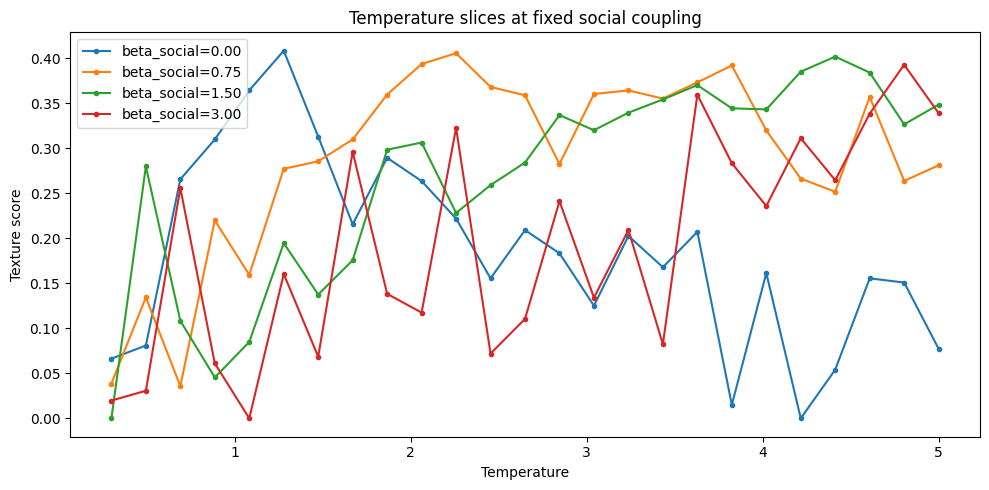

In [6]:
target_social_values = [0.0, 0.75, 1.5, 3.0]
fig, axis = plt.subplots(figsize=(10, 5))
for target in target_social_values:
    index = np.abs(social_values - target).argmin()
    axis.plot(temperatures, texture_score[index], marker='o', markersize=3, label=f'beta_social={social_values[index]:.2f}')
axis.set(xlabel='Temperature', ylabel='Texture score', title='Temperature slices at fixed social coupling')
axis.legend()
fig.tight_layout()

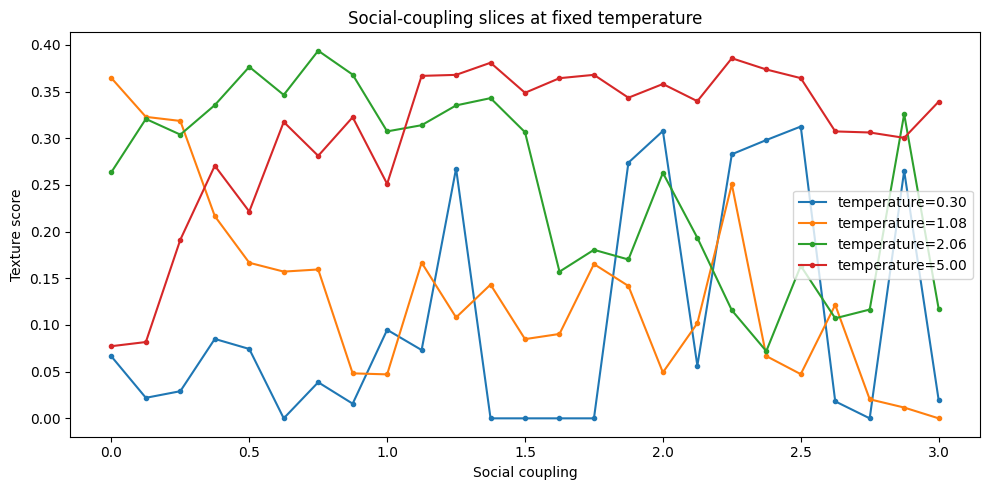

In [7]:
target_temperatures = [0.3, 1.0, 2.0, 5.0]
fig, axis = plt.subplots(figsize=(10, 5))
for target in target_temperatures:
    index = np.abs(temperatures - target).argmin()
    axis.plot(social_values, texture_score[:, index], marker='o', markersize=3, label=f'temperature={temperatures[index]:.2f}')
axis.set(xlabel='Social coupling', ylabel='Texture score', title='Social-coupling slices at fixed temperature')
axis.legend()
fig.tight_layout()

## Interpretation cautions and next experiments

- Every grid cell currently uses one seed. Repeat each cell across several seeds and plot uncertainty.
- Entropy and consonance are normalized globally, so changing the sweep bounds can move the apparent optimum.
- The product score rewards balance but does not encode rhythm, register, orchestration, or listener preference.
- Add sweeps over `beta_memory` and `beta_tuning` to separate smooth motion from attraction to A.
- Compare metric-selected regions through listening tests rather than assuming the numerical optimum sounds best.